In [1]:
import numpy as np

# ФИЗИЧЕСКИЕ КОНСТАНТЫ МОДЕЛИ

rho = 1.225          # плотность воздуха, кг/м³
R = 50.0             # радиус ротора, м
A = np.pi * R**2     # площадь ротора, м^2
P_rated = 5000000    # номинальная мощность, Вт (поставила как в пдф документации к NREL 5-MW )
v_rated = 12.0       # номинальная скорость ветра, м/с
Cp_max = 16/27       # предел Беца

# РАСПРЕДЕЛЕНИЕ ВЕТРА Weibull(k, c)

weibull_k = 2.0      # параметр формы
weibull_c = 8.0      # параметр масштаба, м/с
n_samples = 1000     # число сэмплов Монте-Карло на одну оценку J(θ)

# ОГРАНИЧЕНИЯ НА РЕЖИМ РАБОТЫ

v_cut_in  = 3.0      # скорость включения турбины, м/с
v_cut_out = 25.0     # скорость отключения турбины, м/с

beta_min  = 0.0      # минимальный угол лопастей, градусы
beta_max  = 30.0     # максимальный угол лопастей, градусы

omega_min = 0.0      # минимальная угловая скорость, рад/с
omega_max = 2.0      # максимальная угловая скорость, рад/с

# ПАРАМЕТРЫ ОПТИМИЗАЦИИ θ = (a0, a1, a2, b0, b1)
# Закон управления углом:    β(v) = a0 + a1*(v - v_rated) + a2*(v - v_rated)^2
# Закон управления скоростью: ω(v) = b0 + b1*v

# Границы поиска для каждого параметра [min, max]
bounds = np.array([
    [0.0,  30.0],   # a0 — базовый угол лопастей, градусы
    [-5.0,  5.0],   # a1 — линейный коэффициент β(v)
    [-1.0,  1.0],   # a2 — квадратичный коэффициент β(v)
    [0.0,   2.0],   # b0 — базовая угловая скорость, рад/с
    [0.0,   0.2],   # b1 — линейный коэффициент ω(v)
])

n_dims = len(bounds)  # размерность задачи = 5
lo = bounds[:, 0]
hi = bounds[:, 1]

# КОЭФФИЦИЕНТЫ ШТРАФНОЙ ФУНКЦИИ
# J(θ) = -E[P(v;θ)] + alpha*Var(P) + gamma*E[max(0, P-P_rated)^2] + delta*Penalty_bounds(θ)

alpha = 0.05   # штраф за нестабильность мощности (дисперсию)
gamma = 10.0   # штраф за превышение номинальной мощности
delta = 10.0   # штраф за выход параметров за допустимые границы

In [2]:
# ВСПОМОГАТЕЛЬНЫЕ ФУНКЦИИ УПРАВЛЕНИЯ

def beta_control(v, theta):
    """
    Закон управления углом лопастей.
    β(v) = a0 + a1*(v - v_rated) + a2*(v - v_rated)^2
    Результат обрезается до [beta_min, beta_max].
    """
    a0, a1, a2, b0, b1 = theta
    beta = a0 + a1 * (v - v_rated) + a2 * (v - v_rated)**2
    return np.clip(beta, beta_min, beta_max)


def omega_control(v, theta):
    """
    Закон управления угловой скоростью ротора.
    ω(v) = b0 + b1*v
    Результат обрезается до [omega_min, omega_max].
    """
    a0, a1, a2, b0, b1 = theta
    omega = b0 + b1 * v
    return np.clip(omega, omega_min, omega_max)


def sample_wind(seed=None):
    """
    Сэмплирование скорости ветра из распределения Вейбулла.
    Возвращает только скорости в рабочем диапазоне [v_cut_in, v_cut_out].
    """
    rng = np.random.default_rng(seed)
    v_all = weibull_c * rng.weibull(weibull_k, size=n_samples)
    mask = (v_all >= v_cut_in) & (v_all <= v_cut_out)
    return v_all[mask] if mask.sum() > 0 else np.array([v_rated])

In [3]:
def compute_Cp(lam, beta):
    """
    Аппроксимация коэффициента мощности Cp(λ, β) по формуле Heier.
    Результат обрезается до [0, Cp_max].
    """
    lam = np.where(lam  < 1e-6, 1e-6, lam)
    beta = np.where(beta < 0.0,  0.0,   beta)
    inv = 1.0 / (lam + 0.08 * beta) - 0.035 / (beta**3 + 1.0)
    inv = np.where(np.abs(inv) < 1e-6, 1e-6, inv)
    Cp = (0.5176 * (116.0 * inv - 0.4 * beta - 5.0)
            * np.exp(-21.0 * inv) + 0.0068 * lam)
    return np.clip(Cp, 0.0, Cp_max)

In [4]:
def penalty_bounds(theta):
    """Квадратичный штраф за выход θ за bounds."""
    return float(np.sum(np.maximum(0.0, lo - theta)**2
                      + np.maximum(0.0, theta - hi)**2))

In [5]:
MC_SEED = 999  # глобальная константа, одна для всех методов и запусков

def objective(theta, mc_seed=MC_SEED):
    """
    mc_seed фиксирован → одни и те же реализации ветра при каждом вызове.
    algo_rng больше не попадает сюда.
    """
    v = sample_wind(seed=mc_seed)
    beta  = beta_control(v, theta)
    omega = omega_control(v, theta)
    lam   = omega * R / v
    Cp    = compute_Cp(lam, beta)
    p     = 0.5 * rho * A * Cp * v**3 / P_rated

    return (-np.mean(p)
            + alpha * np.var(p)
            + gamma * np.mean(np.maximum(0.0, p - 1.0)**2)
            + delta  * penalty_bounds(theta))

In [6]:
# ВСПОМОГАТЕЛЬНЫЕ ФУНКЦИИ SPSO-2011

def random_point_in_hypersphere(center, radius, rng):
    """
    Равномерно случайная точка внутри D-мерной гиперсферы H(G, ||G - X||).
    Используется в уравнении (3).
    """
    D = len(center)
    direction = rng.standard_normal(D)
    norm = np.linalg.norm(direction)
    if norm < 1e-12:
        return center.copy()
    direction /= norm
    r = radius * (rng.uniform() ** (1.0 / D))
    return center + r * direction


def build_random_topology(N, K, rng):
    """
    Адаптивная случайная топология (Section II-B).
    Частица j информирует K случайных частиц и саму себя.
    Возвращает informed_by[i] — множество частиц-информантов для i.
    """
    informed_by = [set() for _ in range(N)]
    for j in range(N):
        targets = rng.integers(0, N, size=K).tolist()
        targets.append(j)
        for t in targets:
            informed_by[t].add(j)
    return informed_by

In [7]:
# АЛГОРИТМ SPSO-2011

def spso2011(algo_seed=42, verbose=True):
    """
    SPSO-2011. Псевдокод в статье (стр. 2339)
    """
    algo_rng = np.random.default_rng(algo_seed)  # только для алгоритма

    # ИНИЦИАЛИЗАЦИЯ

    # Xi^0 = U(mind,maxd)
    X = algo_rng.uniform(lo, hi, size=(N, n_dims))

    # Vi^0 = (U(mind,maxd) − Xi^0)/2
    V = (algo_rng.uniform(lo, hi, size=(N, n_dims)) - X) / 2.0

    # pi^0 = Xi^0
    P_best = X.copy()
    P_best_val = np.array([objective(P_best[i]) for i in range(N)])

    # li^0 = argmin f в окрестности -> строим топологию
    informed_by = build_random_topology(N, K, algo_rng)

    L = np.zeros((N, n_dims))
    L_val = np.full(N, np.inf)
    for i in range(N):
        for j in informed_by[i]:
            if P_best_val[j] < L_val[i]:
                L_val[i] = P_best_val[j]
                L[i] = P_best[j].copy()

    best_idx = int(np.argmin(P_best_val))
    best_theta = P_best[best_idx].copy()
    best_J = float(P_best_val[best_idx])
    history = [best_J]
    improved = True

    if verbose:
        print(f"SPSO-2011: N={N}, D={n_dims}, max_iter={max_iter}")
        print(f"w={w:.4f}, c1=c2={c1:.4f}, K={K}")
        print(f"Инициализация завершена. Лучший J₀ = {best_J:.4f}")

    # ГЛАВНЫЙ ЦИКЛ (шаги 5-16)
    
    no_improve = 0

    for t in range(max_iter):

        # Если нет улучшения глобального оптимума, то перестраиваем топологию
        if not improved:
            informed_by = build_random_topology(N, K, algo_rng)
            for i in range(N):
                L_val[i] = np.inf
                for j in informed_by[i]:
                    if P_best_val[j] < L_val[i]:
                        L_val[i] = P_best_val[j]
                        L[i] = P_best[j].copy()

        improved = False

        for i in range(N):

            # p~_i = X_i + c1·U1·(P_i − X_i)
            U1 = algo_rng.uniform(0.0, 1.0, n_dims)
            p_tilde = X[i] + c1 * U1 * (P_best[i] - X[i])

            # (2b)  l~_i = X_i + c2·U2·(L_i − X_i)
            U2 = algo_rng.uniform(0.0, 1.0, n_dims)
            l_tilde = X[i] + c2 * U2 * (L[i]      - X[i])

            # (2c)  G_i = (X_i + p~_i + l~_i) / 3
            G = (X[i] + p_tilde + l_tilde) / 3.0
            radius = np.linalg.norm(G - X[i])

            # (3)   V^{t+1}_i = w·V_i + x' − X_i
            x_prime = random_point_in_hypersphere(G, radius, algo_rng)
            V[i] = w * V[i] + x_prime - X[i]

            # (1b)  X^{t+1}_i = X_i + V^{t+1}_i
            X[i] = X[i] + V[i]

            # Частица достигает границы -> позиция = граница, скорость = 0
            for d in range(n_dims):
                if X[i, d] < lo[d]:
                    X[i, d] = lo[d];  V[i, d] = 0.0
                elif X[i, d] > hi[d]:
                    X[i, d] = hi[d];  V[i, d] = 0.0

            f_new = objective(X[i])

            # Шаг 9–10
            if f_new < P_best_val[i]:
                P_best[i] = X[i].copy()
                P_best_val[i] = f_new

                # Шаг 11–12: обновляем neighbourhood best для всех,
                # кто получает информацию от частицы i
                for k in range(N):
                    if i in informed_by[k] and P_best_val[i] < L_val[k]:
                        L_val[k] = P_best_val[i]
                        L[k] = P_best[i].copy()

                # Обновляем глобально лучшее
                if f_new < best_J:
                    best_J = f_new
                    best_theta = X[i].copy()
                    improved = True
                    no_improve = 0

        history.append(best_J)
        if not improved:
            no_improve += 1

        if verbose and (t + 1) % 100 == 0:
            print(f"iter {t+1:4d} best J = {best_J:>14.4f}"
                  f" no-improve = {no_improve}")

    if verbose:
        print(f"Готово.  J* = {best_J:.6f}")
        for name, val in zip(["a0","a1","a2","b0","b1"], best_theta):
            print(f"  {name} = {val:+.6f}")

    return best_theta, best_J, history

In [8]:
# ПАРАМЕТРЫ SPSO-2011  (из статьи Section III)
N = 40
max_iter = 500
w = 1.0 / (2.0 * np.log(2.0))
c1 = 0.5 + np.log(2.0)
c2 = 0.5 + np.log(2.0)
K = 3

In [9]:
import json
import numpy as np

n_runs = 15
all_J         = []
all_histories = []
all_thetas    = []

for run_idx in range(n_runs):
    print(f"\nЗапуск {run_idx+1}/{n_runs}  (algo_seed={run_idx})")
    theta, J, history = spso2011(algo_seed=run_idx, verbose=False)
    print(f"  J* = {J:.6f}  |  θ* = [{', '.join(f'{x:.4f}' for x in theta)}]")  # ← добавить
    all_J.append(J)
    all_histories.append(history)
    all_thetas.append(theta.tolist())

best_run   = int(np.argmin(all_J))
theta_best = np.array(all_thetas[best_run])
best_J     = all_J[best_run]

# Сохранение для статистического анализа
results = {
    # идентификация
    "method":       "SPSO-2011",
    "n_runs":       n_runs,
    "algo_seeds":   list(range(n_runs)),   # algo_seed = 0..14
    "mc_seed":      MC_SEED,               # 999 одинаковый у всех методов

    # главное для статтестов
    "final_J":      all_J,                 # список из 15 чисел — основная выборка

    # для графиков сходимости
    "histories":    [h for h in all_histories],  # 15 × (max_iter+1)

    # лучшее найденное решение
    "best_run_idx": best_run,
    "theta_best":   theta_best.tolist(),
    "best_J":       float(best_J),

    # гиперпараметры — чтобы коллеги знали условия
    "hyperparams": {
        "N":        N,
        "max_iter": max_iter,
        "w":        w,
        "c1":       c1,
        "c2":       c2,
        "K":        K,
        "n_samples_MC": n_samples
    }
}

with open("spso2011_results.json", "w", encoding="utf-8") as f:
    json.dump(results, f, indent=2, ensure_ascii=False)

print(f"\nСохранено: spso2011_results.json")
print(f"best J = {best_J:.6f}  (запуск #{best_run})")
print(f"median J = {np.median(all_J):.6f}")
print(f"std    J = {np.std(all_J):.6f}")


Запуск 1/15  (algo_seed=0)
  J* = -0.289207  |  θ* = [0.0000, 1.1857, 0.1488, 0.0131, 0.1604]

Запуск 2/15  (algo_seed=1)
  J* = -0.289207  |  θ* = [0.0000, 1.1904, 0.1488, 0.0127, 0.1606]

Запуск 3/15  (algo_seed=2)
  J* = -0.289208  |  θ* = [0.0000, 1.1838, 0.1488, 0.0111, 0.1607]

Запуск 4/15  (algo_seed=3)
  J* = -0.289207  |  θ* = [0.0000, 1.1901, 0.1485, 0.0093, 0.1610]

Запуск 5/15  (algo_seed=4)
  J* = -0.289196  |  θ* = [0.0000, 1.2057, 0.1478, 0.0013, 0.1621]

Запуск 6/15  (algo_seed=5)
  J* = -0.289207  |  θ* = [0.0000, 1.1803, 0.1488, 0.0120, 0.1606]

Запуск 7/15  (algo_seed=6)
  J* = -0.289208  |  θ* = [0.0000, 1.1865, 0.1489, 0.0095, 0.1610]

Запуск 8/15  (algo_seed=7)
  J* = -0.289207  |  θ* = [0.0000, 1.1896, 0.1486, 0.0108, 0.1608]

Запуск 9/15  (algo_seed=8)
  J* = -0.289196  |  θ* = [0.0000, 1.1869, 0.1499, 0.0306, 0.1586]

Запуск 10/15  (algo_seed=9)
  J* = -0.289208  |  θ* = [0.0000, 1.1843, 0.1488, 0.0142, 0.1604]

Запуск 11/15  (algo_seed=10)
  J* = -0.289199  |

In [10]:
# Лучший запуск для итогового графика
best_run = int(np.argmin(all_J))
theta_best = all_thetas[best_run]


График сохранен: spso2011_results.png


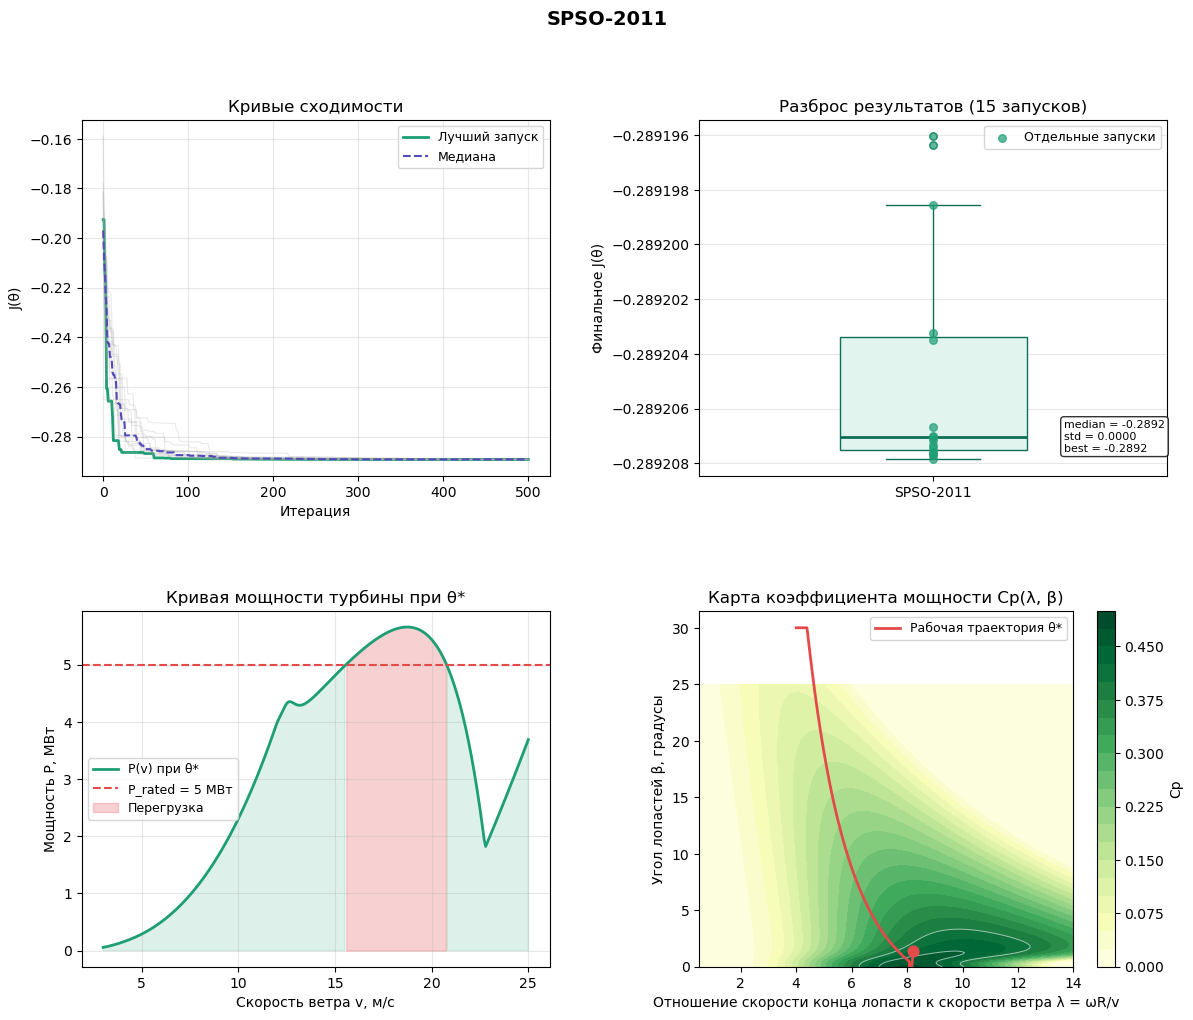

In [11]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(14, 11))
fig.suptitle("SPSO-2011",
             fontsize=14, fontweight="bold", y=0.98)
 
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.38, wspace=0.32)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])
 
iterations = np.arange(max_iter + 1)
 
# Кривые сходимости
for i, hist in enumerate(all_histories):
    alpha_line = 0.25 if i != best_run else 1.0
    lw = 0.8  if i != best_run else 2.0
    color = "#aaaaaa" if i != best_run else "#1D9E75"
    ax1.plot(iterations, hist, color=color, lw=lw,
             alpha=alpha_line,
             label="Лучший запуск" if i == best_run else None)
 
ax1.set_xlabel("Итерация")
ax1.set_ylabel("J(θ)")
ax1.set_title("Кривые сходимости")
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)
 
# Медианная кривая
median_hist = np.median(np.array(all_histories), axis=0)
ax1.plot(iterations, median_hist, color="#534AB7",
         lw=1.5, ls="--", label="Медиана")
ax1.legend(fontsize=9)
 
 
# Боксплот финальных J
bp = ax2.boxplot(all_J, vert=True, patch_artist=True,
                 widths=0.4,
                 boxprops=dict(facecolor="#E1F5EE", color="#0F6E56"),
                 medianprops=dict(color="#0F6E56", lw=2),
                 whiskerprops=dict(color="#0F6E56"),
                 capprops=dict(color="#0F6E56"),
                 flierprops=dict(marker="o", color="#0F6E56",
                                 markersize=5, alpha=0.6))
 
ax2.scatter([1]*n_runs, all_J, color="#1D9E75",
            s=30, zorder=5, alpha=0.7, label="Отдельные запуски")
ax2.set_xticks([1])
ax2.set_xticklabels(["SPSO-2011"])
ax2.set_ylabel("Финальное J(θ)")
ax2.set_title(f"Разброс результатов ({n_runs} запусков)")
ax2.grid(True, axis="y", alpha=0.3)
ax2.legend(fontsize=9)
 
stats_text = (f"median = {np.median(all_J):.4f}\n"
              f"std = {np.std(all_J):.4f}\n"
              f"best = {np.min(all_J):.4f}")
ax2.text(1.28, np.median(all_J), stats_text,
         fontsize=8, va="center",
         bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.8))
 
 
# P(v) при θ*
v_range = np.linspace(v_cut_in, v_cut_out, 300)
beta_v  = beta_control(v_range, theta_best)
omega_v = omega_control(v_range, theta_best)
lam_v   = omega_v * R / v_range
Cp_v    = compute_Cp(lam_v, beta_v)
P_v     = 0.5 * rho * A * Cp_v * v_range**3 / 1e6  # в МВт
 
ax3.plot(v_range, P_v, color="#1D9E75", lw=2, label="P(v) при θ*")
ax3.axhline(P_rated / 1e6, color="#E24B4A", lw=1.5,
            ls="--", label=f"P_rated = {P_rated/1e6:.0f} МВт")
ax3.fill_between(v_range, 0, P_v,
                 where=(P_v <= P_rated / 1e6),
                 alpha=0.15, color="#1D9E75")
ax3.fill_between(v_range, 0, P_v,
                 where=(P_v > P_rated / 1e6),
                 alpha=0.25, color="#E24B4A", label="Перегрузка")
ax3.set_xlabel("Скорость ветра v, м/с")
ax3.set_ylabel("Мощность P, МВт")
ax3.set_title("Кривая мощности турбины при θ*")
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3)
 
 
# Карта Cp(λ, β)
lam_grid  = np.linspace(0.5, 14, 200)
beta_grid = np.linspace(0, 25, 200)
LAM, BETA = np.meshgrid(lam_grid, beta_grid)
CP_MAP = compute_Cp(LAM, BETA)
 
cf = ax4.contourf(LAM, BETA, CP_MAP, levels=20, cmap="YlGn")
fig.colorbar(cf, ax=ax4, label="Cp")
ax4.contour(LAM, BETA, CP_MAP, levels=[0.4, 0.45, 0.48, 0.5, 0.52],
            colors="white", linewidths=0.7, alpha=0.6)
 
# Рабочая траектория при θ*
ax4.plot(lam_v, beta_v, color="#E24B4A", lw=2,
         label="Рабочая траектория θ*")
ax4.scatter(lam_v[0], beta_v[0], color="#E24B4A",
            s=60, zorder=5, marker="o")
 
ax4.set_xlabel("Отношение скорости конца лопасти к скорости ветра λ = ωR/v")
ax4.set_ylabel("Угол лопастей β, градусы")
ax4.set_title("Карта коэффициента мощности Cp(λ, β)")
ax4.legend(fontsize=9)
 
 
plt.savefig("spso2011_results.png", dpi=150, bbox_inches="tight")
print("\nГрафик сохранен: spso2011_results.png")
plt.show()